# Sequence and structural homology comparisons
This notebook contains the code to generate the subplots for Figure 5 of the section 'Beyond sequence similarity'.

## Structural comparison
With structural comparison data exported from the TM-Align webserver.

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [8]:
rmsd_file = 'pairwise_rmsd.txt'  # from TM-Align Pairwise RMSD
df_rmsd = pd.read_csv(rmsd_file, delim_whitespace=True)
df_rmsd

/tmp/ipykernel_8763/3891294482.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_rmsd = pd.read_csv(rmsd_file, delim_whitespace=True)


,1,1a,2,3,4,5,6,7
1,0.000,0.440,1.574,2.573,3.017,3.049,2.974,3.784
1a,0.440,0.000,1.635,2.564,3.027,3.043,2.988,3.827
2,1.574,1.635,0.000,2.674,2.992,2.992,2.984,3.743
3,2.573,2.564,2.674,0.000,2.489,2.498,2.529,2.870
4,3.017,3.027,2.992,2.489,0.000,1.740,1.572,4.538
5,3.049,3.043,2.992,2.498,1.740,0.000,0.991,4.778
6,2.974,2.988,2.984,2.529,1.572,0.991,0.000,4.744
7,3.784,3.827,3.743,2.870,4.538,4.778,4.744,0.000


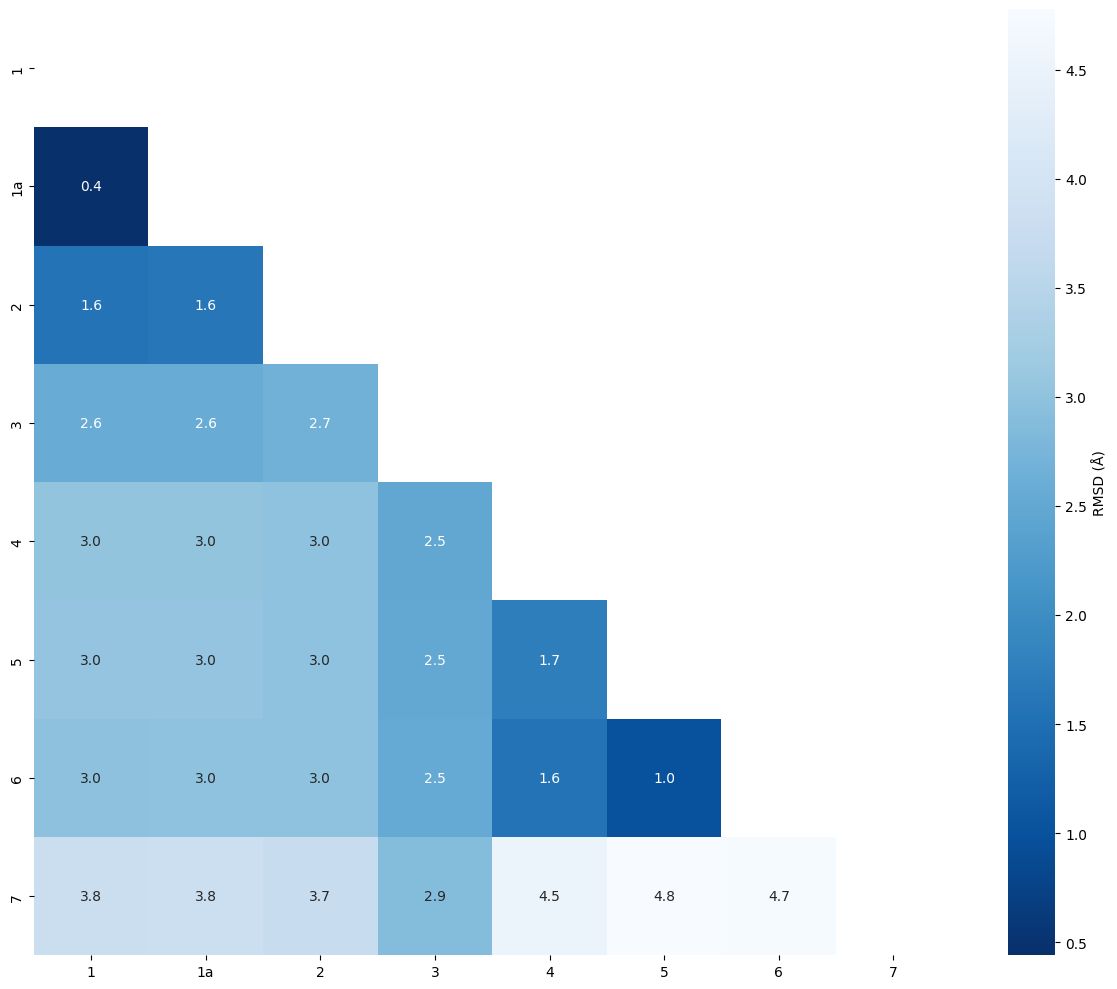

In [9]:
# Getting the Upper Triangle of the co-relation matrix
corr= df_rmsd.corr()
matrix = np.triu(corr)

plt.figure(figsize=(12, 10))
sns.heatmap(df_rmsd, cmap='Blues_r', fmt='.1f', cbar_kws={'label': 'RMSD (Å)'}, mask=matrix, annot=True)  # , annot_kws={"fontsize":20})
# plt.title('Pairwise Structural Similarity')
# plt.xlabel('Structures', fontsize=18)
# plt.ylabel('Structures', fontsize=18)
# plt.xticks(fontsize=20)
# plt.yticks(fontsize=20)
# plt.xticks(rotation=90)
plt.tight_layout()
# plt.savefig('pairwise_rmsd.png', dpi=300)
plt.show()

## Sequence alignment based comparison
Note: The MSA was performed externally, using the ClustalO web tool from EBI (See methods section of the paper)

In [10]:
# raw data output from the MSA
raw = r"""
1: 4|           100.00   35.03   33.97   16.78   14.86   12.74   14.76   13.27
2: 5|            35.03  100.00   58.62   18.09   15.65   15.64   19.62   17.62
3: 6|            33.97   58.62  100.00   17.54   15.65   13.27   19.14   15.24
4: 7|            16.78   18.09   17.54  100.00   14.67   18.65   16.40   17.93
5: 3|            14.86   15.65   15.65   14.67  100.00   16.22   18.03   17.39
6: 2|            12.74   15.64   13.27   18.65   16.22  100.00   27.74   27.27
7: 1|            14.76   19.62   19.14   16.40   18.03   27.74  100.00   63.44
8: 1a|           13.27   17.62   15.24   17.93   17.39   27.27   63.44  100.00"""

In [11]:
# We'll parse the provided Clustal Percent Identity Matrix text,
# extract the first token of each sequence ID (before the first '|'),
# build a numeric matrix from the trailing floats on each line,
# and render a heatmap using seaborn for consistency (replacing previous matplotlib imshow usage).

# Parse lines with "index:" and build rows
lines = [ln for ln in raw.splitlines() if re.match(r"\s*\d+:\s", ln)]
n = len(lines)

ids = []
rows = []

for ln in lines:
    # Extract label after the colon, take first token before first '|'
    after_colon = ln.split(":", 1)[1].lstrip()
    first_token = after_colon.split("|", 1)[0].strip()
    ids.append(first_token)
    # Extract all floats from the line and take the last n of them (matrix is nxn)
    floats = re.findall(r"\d+\.\d+", ln)
    row_vals = list(map(float, floats[-n:]))
    rows.append(row_vals)

mat = np.array(rows)

# Define the desired order of IDs
desired_order = ['1', '1a', '2', '3', '4', '5', '6', '7']

# Create a mapping of the current indices to the desired order
order_indices = [ids.index(label) for label in desired_order]

# Reorder the `ids` list and the `mat` matrix
ids = [ids[i] for i in order_indices]
mat = mat[np.ix_(order_indices, order_indices)]

# Build upper-triangle mask so we plot only the lower triangle (like above)
mask = np.triu(np.ones_like(mat, dtype=bool))

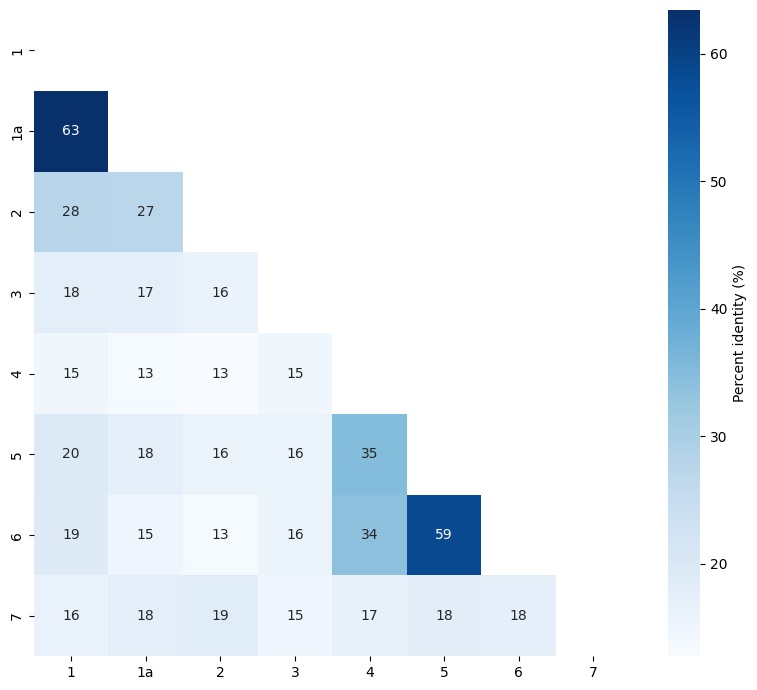

In [12]:
# Plot heatmap with seaborn
plt.figure(figsize=(8, 7))
#ax = sns.heatmap(mat, vmin=0, vmax=100, cmap="Blues", xticklabels=ids, yticklabels=ids, cbar=True, mask=mask, annot=True)  # , annot_kws={"fontsize":20})
ax = sns.heatmap(mat, cmap="Blues", xticklabels=ids, yticklabels=ids, mask=mask, annot=True)  # , annot_kws={"fontsize":20})
# ax.set_title("Pairwise Sequence Identity")
ax.set_xlabel("")
ax.set_ylabel("")
# Rotate x tick labels for readability
ax.set_xticklabels(ax.get_xticklabels())
# Ensure colorbar label
if ax.collections and ax.collections[0].colorbar:
    ax.collections[0].colorbar.set_label("Percent identity (%)")

plt.tight_layout()
plt.show()
